In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("customer_analytics_dataset.csv")

In [9]:
df.head()

,customer_id,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,customer_since,loyalty_score,churn_risk
0,CUST_8270,30,Female,Brazil,101.08,8,176,1,Beauty,25.6,2024-06-05,50,0.20
1,CUST_1860,53,Female,USA,90.39,10,88,0,Electronics,12.3,2024-02-19,37,0.34
2,CUST_6390,73,Male,Australia,83.28,6,203,0,Sports,NaN,2024-04-16,65,0.05
3,CUST_6191,30,Other,Japan,109.90,9,346,1,Electronics,42.9,2020-07-08,93,0.19
4,CUST_6734,29,Female,Canada,269.38,16,342,0,Fashion,5.3,2025-04-09,79,0.15


In [10]:
df.shape

(5000, 13)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         5000 non-null   object 
 1   age                 5000 non-null   int64  
 2   gender              5000 non-null   object 
 3   country             5000 non-null   object 
 4   avg_order_value     4750 non-null   float64
 5   total_orders        5000 non-null   int64  
 6   last_purchase       5000 non-null   int64  
 7   is_fraudulent       5000 non-null   int64  
 8   preferred_category  5000 non-null   object 
 9   email_open_rate     4750 non-null   float64
 10  customer_since      5000 non-null   object 
 11  loyalty_score       5000 non-null   int64  
 12  churn_risk          5000 non-null   float64
dtypes: float64(3), int64(5), object(5)
memory usage: 507.9+ KB


In [12]:
df.isnull().sum()

,0
customer_id,0
age,0
gender,0
country,0
avg_order_value,250
total_orders,0
last_purchase,0
is_fraudulent,0
preferred_category,0
email_open_rate,250


In [13]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

,0
customer_id,0.0
age,0.0
gender,0.0
country,0.0
avg_order_value,5.0
total_orders,0.0
last_purchase,0.0
is_fraudulent,0.0
preferred_category,0.0
email_open_rate,5.0


In [14]:
df["avg_order_value"] = df["avg_order_value"].fillna(
    df["avg_order_value"].median()
)

df["email_open_rate"] = df["email_open_rate"].fillna(
    df["email_open_rate"].median()
)

In [15]:
df.isnull().sum()

,0
customer_id,0
age,0
gender,0
country,0
avg_order_value,0
total_orders,0
last_purchase,0
is_fraudulent,0
preferred_category,0
email_open_rate,0


In [16]:
df.describe()

,age,avg_order_value,total_orders,last_purchase,is_fraudulent,email_open_rate,loyalty_score,churn_risk
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,48.163200,107.680214,10.027000,180.073200,0.025800,50.726600,50.039400,0.284484
std,17.880797,67.593171,3.163838,104.926518,0.158554,28.361808,28.832151,0.159690
min,18.000000,10.660000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,33.000000,59.560000,8.000000,89.000000,0.000000,26.400000,25.000000,0.160000
50%,48.000000,93.190000,10.000000,178.000000,0.000000,50.950000,50.000000,0.260000
75%,64.000000,138.807500,12.000000,270.000000,0.000000,75.300000,75.000000,0.390000
max,79.000000,555.460000,23.000000,364.000000,1.000000,100.000000,99.000000,0.900000


In [17]:
df["country"].value_counts()

,count
country,
Australia,518
USA,517
India,511
Germany,509
Brazil,504
France,500
China,497
Canada,490
UK,485


In [18]:
df["preferred_category"].value_counts()

,count
preferred_category,
Beauty,1035
Electronics,1021
Home,1004
Fashion,975
Sports,965


In [19]:
total_customers = df["customer_id"].nunique()

print("Total Customers:", total_customers)

Total Customers: 3809


In [20]:
total_orders = df["total_orders"].sum()

print("Total Orders:", total_orders)

Total Orders: 50135


In [21]:
average_order_value = df["avg_order_value"].mean()

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 107.68


In [22]:
average_churn_risk = df["churn_risk"].mean()

print("Average Churn Risk:", round(average_churn_risk, 2))

Average Churn Risk: 0.28


In [23]:
fraudulent_customers = df["is_fraudulent"].sum()

print("Fraudulent Customers:", fraudulent_customers)

Fraudulent Customers: 129


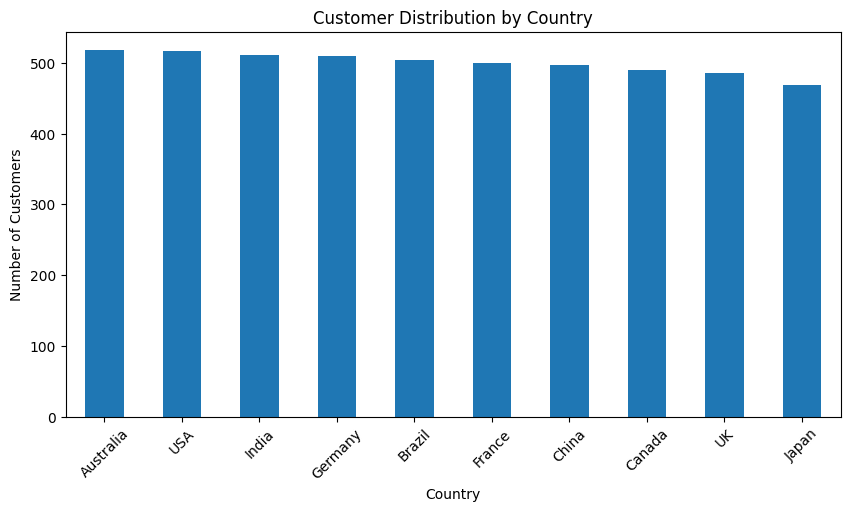

In [24]:
country_counts = df["country"].value_counts()

plt.figure(figsize=(10, 5))

country_counts.plot(kind="bar")

plt.title("Customer Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.show()

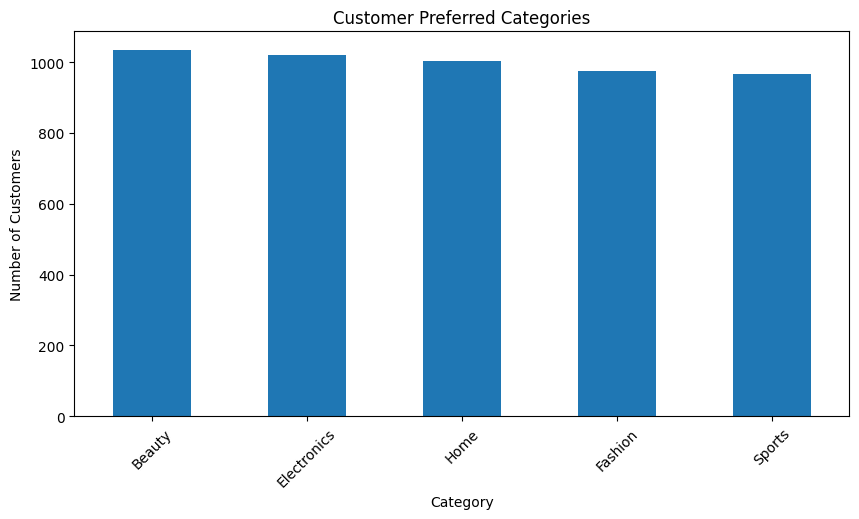

In [25]:
category_counts = df["preferred_category"].value_counts()

plt.figure(figsize=(10, 5))

category_counts.plot(kind="bar")

plt.title("Customer Preferred Categories")
plt.xlabel("Category")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.show()

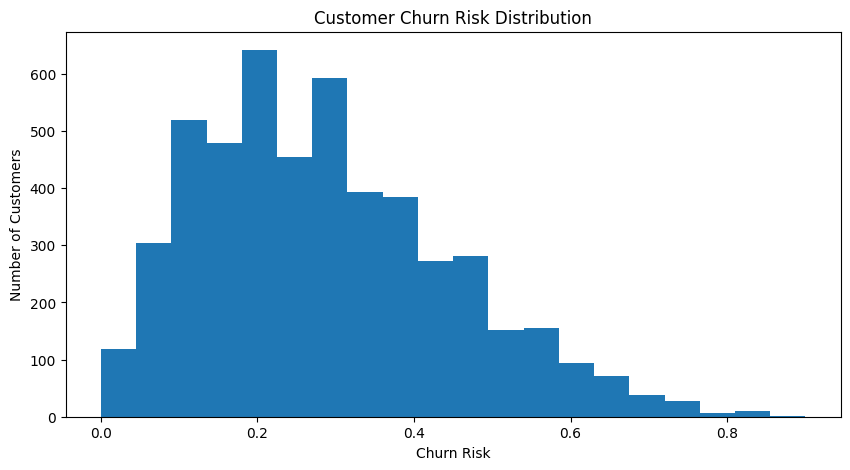

In [26]:
plt.figure(figsize=(10, 5))

plt.hist(df["churn_risk"], bins=20)

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Churn Risk")
plt.ylabel("Number of Customers")

plt.show()

In [27]:
df["churn_risk"].describe()

,churn_risk
count,5000.000000
mean,0.284484
std,0.159690
min,0.000000
25%,0.160000
50%,0.260000
75%,0.390000
max,0.900000


In [29]:
def risk_category(score):

    if score <= 0.30:
        return "Low Risk"

    elif score <= 0.60:
        return "Medium Risk"

    else:
        return "High Risk"


df["risk_category"] = df["churn_risk"].apply(risk_category)

In [33]:
df["risk_category"].value_counts()

,count
risk_category,
Low Risk,2985
Medium Risk,1820
High Risk,195


In [35]:
df["risk_category"].value_counts()

,count
risk_category,
Low Risk,2985
Medium Risk,1820
High Risk,195


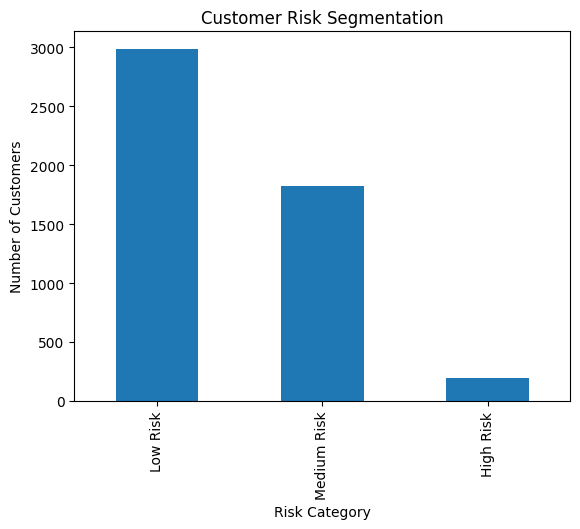

In [36]:
df["risk_category"].value_counts().plot(kind="bar")

plt.title("Customer Risk Segmentation")
plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")

plt.show()

In [37]:
high_risk_customers = df[df["risk_category"] == "High Risk"]

high_risk_customers.head()

,customer_id,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,customer_since,loyalty_score,churn_risk,risk_category
12,CUST_7949,19,Male,India,77.24,12,128,0,Home,26.5,2021-06-28,45,0.63,High Risk
14,CUST_6311,73,Female,India,131.23,7,41,0,Sports,80.3,2024-05-21,35,0.61,High Risk
84,CUST_6258,71,Female,USA,49.42,8,127,0,Beauty,31.5,2025-03-10,41,0.64,High Risk
158,CUST_4581,44,Male,USA,124.35,10,325,0,Electronics,86.0,2024-09-18,13,0.74,High Risk
313,CUST_3806,24,Other,France,80.57,11,320,0,Beauty,32.5,2024-10-24,28,0.70,High Risk


In [38]:
high_risk_customers[[
    "avg_order_value",
    "total_orders",
    "loyalty_score",
    "churn_risk"
]].describe()

,avg_order_value,total_orders,loyalty_score,churn_risk
count,195.000000,195.000000,195.000000,195.000000
mean,108.630205,9.635897,47.538462,0.681077
std,68.838292,3.325277,29.416005,0.062072
min,18.950000,3.000000,1.000000,0.610000
25%,59.785000,7.000000,19.500000,0.630000
50%,90.530000,9.000000,47.000000,0.670000
75%,139.380000,12.000000,73.000000,0.710000
max,389.320000,21.000000,99.000000,0.900000


In [39]:
risk_analysis = df.groupby("risk_category")[
    [
        "avg_order_value",
        "total_orders",
        "loyalty_score",
        "churn_risk"
    ]
].mean()

risk_analysis

,avg_order_value,total_orders,loyalty_score,churn_risk
risk_category,,,,
High Risk,108.630205,9.635897,47.538462,0.681077
Low Risk,106.360858,9.976884,50.052261,0.177022
Medium Risk,109.742319,10.151099,50.286264,0.418242


In [40]:
risk_analysis = df.groupby("risk_category")[
    [
        "avg_order_value",
        "total_orders",
        "loyalty_score",
        "churn_risk"
    ]
].mean()

risk_analysis

,avg_order_value,total_orders,loyalty_score,churn_risk
risk_category,,,,
High Risk,108.630205,9.635897,47.538462,0.681077
Low Risk,106.360858,9.976884,50.052261,0.177022
Medium Risk,109.742319,10.151099,50.286264,0.418242


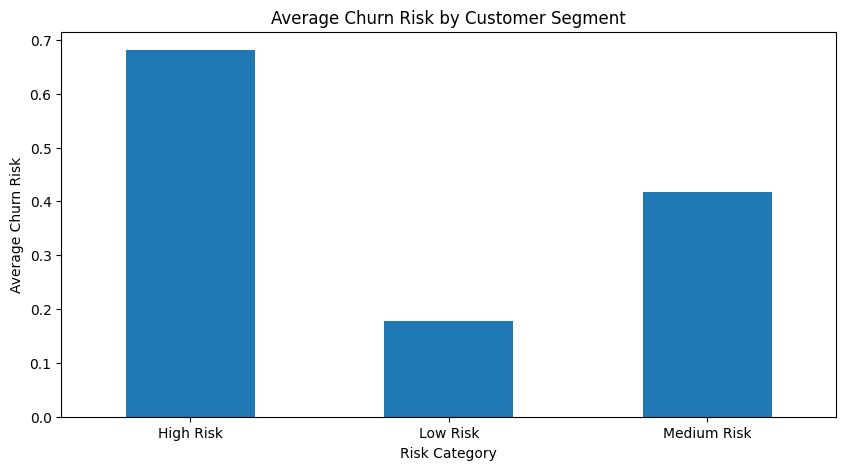

In [41]:
plt.figure(figsize=(10, 5))

risk_analysis["churn_risk"].plot(kind="bar")

plt.title("Average Churn Risk by Customer Segment")
plt.xlabel("Risk Category")
plt.ylabel("Average Churn Risk")

plt.xticks(rotation=0)
plt.show()

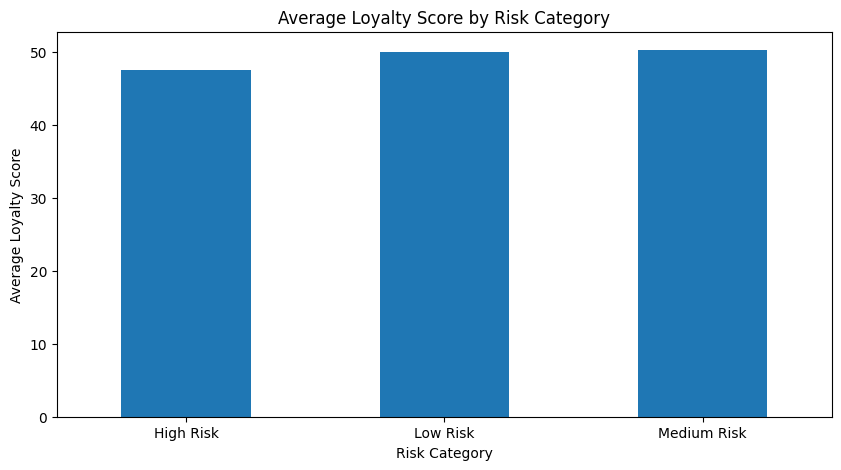

In [42]:
plt.figure(figsize=(10, 5))

risk_analysis["loyalty_score"].plot(kind="bar")

plt.title("Average Loyalty Score by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Average Loyalty Score")

plt.xticks(rotation=0)
plt.show()

In [43]:
difference = (
    risk_analysis.loc["Low Risk", "loyalty_score"]
    - risk_analysis.loc["High Risk", "loyalty_score"]
)

print("Loyalty Score Difference:", round(difference, 2))

Loyalty Score Difference: 2.51


In [44]:
fraud_counts = df["is_fraudulent"].value_counts()

fraud_counts

,count
is_fraudulent,
0,4871
1,129


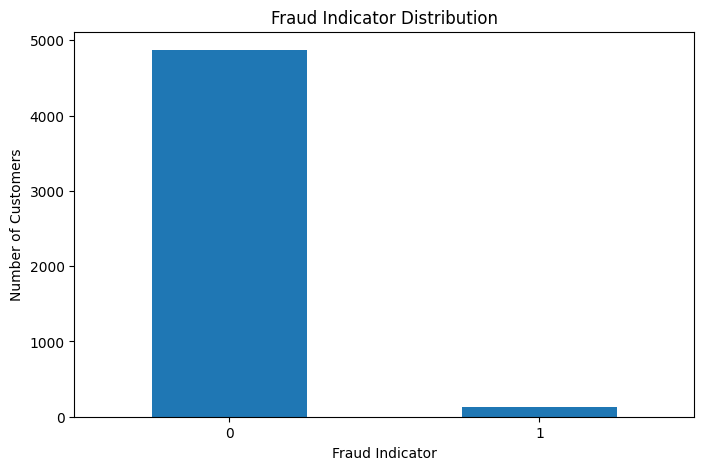

In [45]:
plt.figure(figsize=(8, 5))

fraud_counts.plot(kind="bar")

plt.title("Fraud Indicator Distribution")
plt.xlabel("Fraud Indicator")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.show()

In [46]:
fraud_percentage = (
    df["is_fraudulent"].mean() * 100
)

print("Fraud Indicator Percentage:", round(fraud_percentage, 2), "%")

Fraud Indicator Percentage: 2.58 %


In [47]:
fraud_risk_analysis = df.groupby("is_fraudulent")[
    ["churn_risk", "avg_order_value", "total_orders"]
].mean()

fraud_risk_analysis

,churn_risk,avg_order_value,total_orders
is_fraudulent,,,
0,0.284576,107.793621,10.025867
1,0.281008,103.397984,10.069767


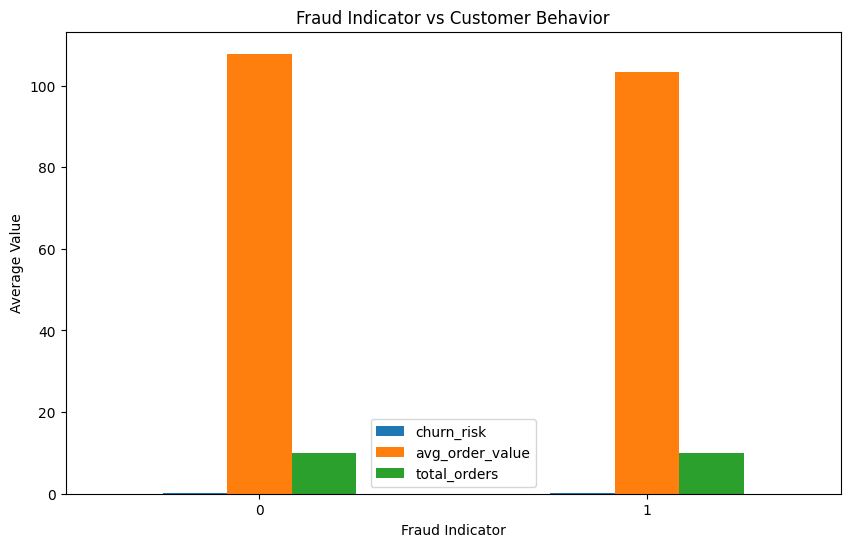

In [48]:
fraud_risk_analysis.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Fraud Indicator vs Customer Behavior")
plt.xlabel("Fraud Indicator")
plt.ylabel("Average Value")

plt.xticks(rotation=0)
plt.legend()
plt.show()

In [49]:
  df["estimated_revenue"] = (
    df["avg_order_value"] * df["total_orders"]
)

df.head()

,customer_id,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,customer_since,loyalty_score,churn_risk,risk_category,estimated_revenue
0,CUST_8270,30,Female,Brazil,101.08,8,176,1,Beauty,25.60,2024-06-05,50,0.20,Low Risk,808.64
1,CUST_1860,53,Female,USA,90.39,10,88,0,Electronics,12.30,2024-02-19,37,0.34,Medium Risk,903.90
2,CUST_6390,73,Male,Australia,83.28,6,203,0,Sports,50.95,2024-04-16,65,0.05,Low Risk,499.68
3,CUST_6191,30,Other,Japan,109.90,9,346,1,Electronics,42.90,2020-07-08,93,0.19,Low Risk,989.10
4,CUST_6734,29,Female,Canada,269.38,16,342,0,Fashion,5.30,2025-04-09,79,0.15,Low Risk,4310.08


In [50]:
country_revenue = df.groupby("country")[
    "estimated_revenue"
].sum().sort_values(ascending=False)

country_revenue

,estimated_revenue
country,
Brazil,584229.69
USA,576266.73
India,575631.08
Australia,547868.16
Germany,542089.59
Canada,541864.43
China,533260.05
France,513078.09
Japan,507896.86


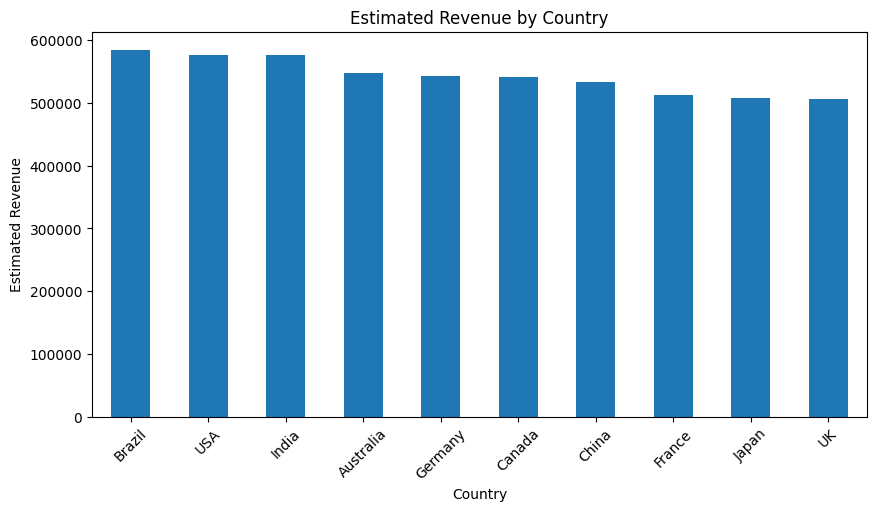

In [51]:
plt.figure(figsize=(10, 5))

country_revenue.plot(kind="bar")

plt.title("Estimated Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Estimated Revenue")

plt.xticks(rotation=45)
plt.show()

In [52]:
category_revenue = df.groupby("preferred_category")[
    "estimated_revenue"
].sum().sort_values(ascending=False)

category_revenue

,estimated_revenue
preferred_category,
Electronics,1117129.20
Home,1084804.33
Beauty,1083590.85
Fashion,1077007.32
Sports,1065421.86


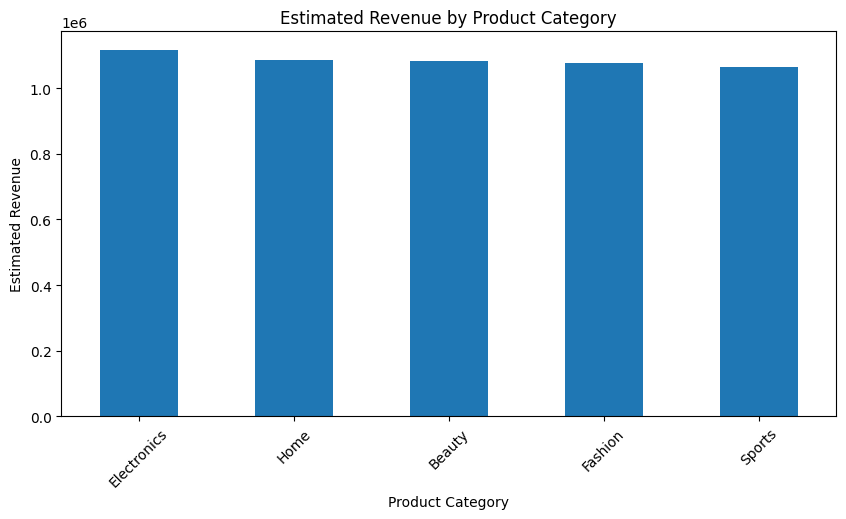

In [53]:
plt.figure(figsize=(10, 5))

category_revenue.plot(kind="bar")

plt.title("Estimated Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Estimated Revenue")

plt.xticks(rotation=45)
plt.show()

In [54]:
df["customer_since"] = pd.to_datetime(
    df["customer_since"]
)

df["customer_since"].head()

,customer_since
0,2024-06-05
1,2024-02-19
2,2024-04-16
3,2020-07-08
4,2025-04-09


In [55]:
customers_by_year = (
    df["customer_since"]
    .dt.year
    .value_counts()
    .sort_index()
)

customers_by_year

,count
customer_since,
2020,542
2021,959
2022,964
2023,1006
2024,1042
2025,487


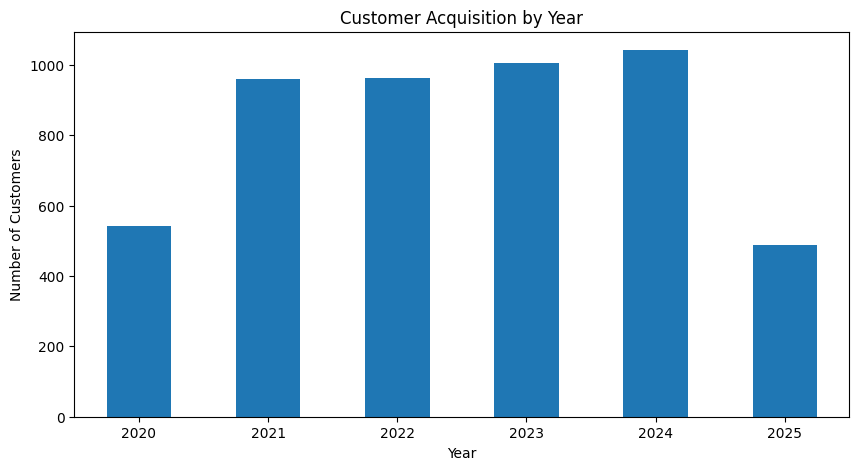

In [56]:
plt.figure(figsize=(10, 5))

customers_by_year.plot(kind="bar")

plt.title("Customer Acquisition by Year")
plt.xlabel("Year")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.show()

In [57]:
def age_group(age):

    if age < 25:
        return "Young"

    elif age < 40:
        return "Adult"

    elif age < 60:
        return "Middle Age"

    else:
        return "Senior"


df["age_group"] = df["age"].apply(age_group)

df.head()

,customer_id,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,customer_since,loyalty_score,churn_risk,risk_category,estimated_revenue,age_group
0,CUST_8270,30,Female,Brazil,101.08,8,176,1,Beauty,25.60,2024-06-05,50,0.20,Low Risk,808.64,Adult
1,CUST_1860,53,Female,USA,90.39,10,88,0,Electronics,12.30,2024-02-19,37,0.34,Medium Risk,903.90,Middle Age
2,CUST_6390,73,Male,Australia,83.28,6,203,0,Sports,50.95,2024-04-16,65,0.05,Low Risk,499.68,Senior
3,CUST_6191,30,Other,Japan,109.90,9,346,1,Electronics,42.90,2020-07-08,93,0.19,Low Risk,989.10,Adult
4,CUST_6734,29,Female,Canada,269.38,16,342,0,Fashion,5.30,2025-04-09,79,0.15,Low Risk,4310.08,Adult


In [58]:
age_group_counts = df["age_group"].value_counts()

age_group_counts

,count
age_group,
Middle Age,1624
Senior,1554
Adult,1263
Young,559


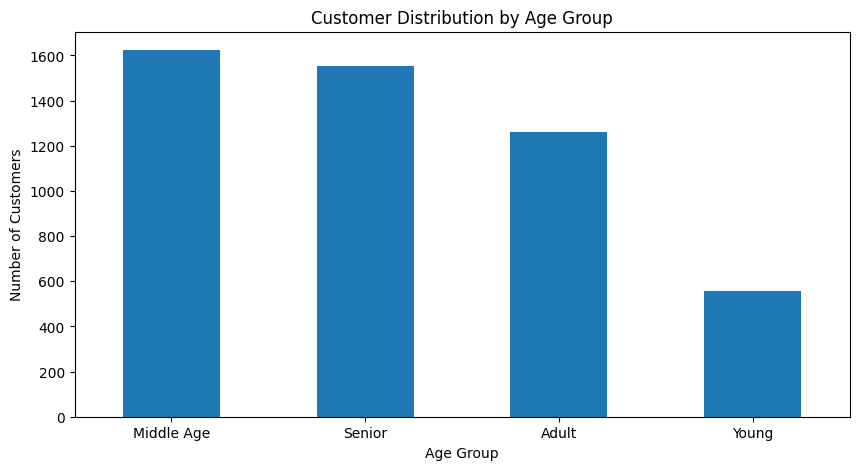

In [59]:
plt.figure(figsize=(10, 5))

age_group_counts.plot(kind="bar")

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.show()

In [60]:
age_revenue = df.groupby("age_group")[
    "estimated_revenue"
].sum().sort_values(ascending=False)

age_revenue

,estimated_revenue
age_group,
Senior,1729735.17
Middle Age,1717691.35
Adult,1400485.82
Young,580041.22


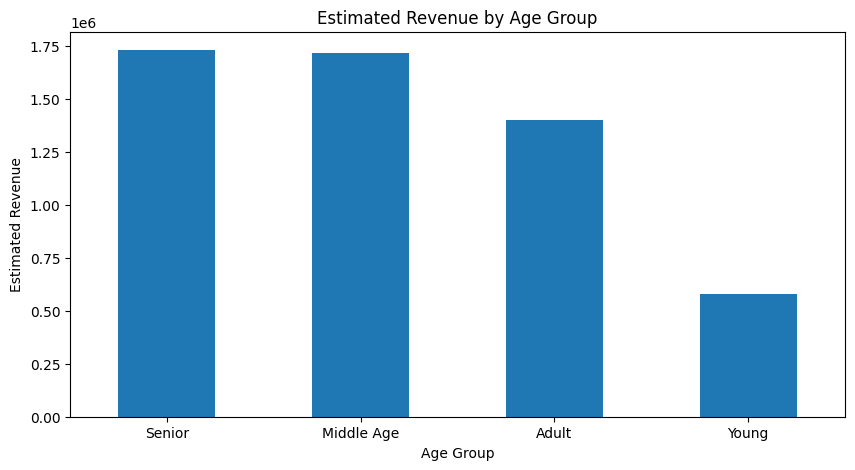

In [61]:
plt.figure(figsize=(10, 5))

age_revenue.plot(kind="bar")

plt.title("Estimated Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Estimated Revenue")

plt.xticks(rotation=0)
plt.show()

In [62]:
gender_revenue = df.groupby("gender")[
    "estimated_revenue"
].sum().sort_values(ascending=False)

gender_revenue

,estimated_revenue
gender,
Male,2521557.07
Female,2364003.25
Other,542393.24


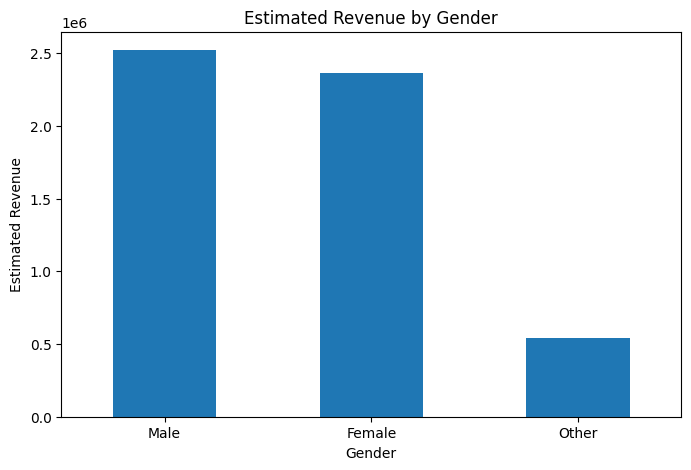

In [63]:
plt.figure(figsize=(8, 5))

gender_revenue.plot(kind="bar")

plt.title("Estimated Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Estimated Revenue")

plt.xticks(rotation=0)
plt.show()

In [64]:
country_category_revenue = df.pivot_table(
    values="estimated_revenue",
    index="country",
    columns="preferred_category",
    aggfunc="sum",
    fill_value=0
)

country_category_revenue

preferred_category,Beauty,Electronics,Fashion,Home,Sports
country,,,,,
Australia,108952.79,109088.17,108537.91,106319.68,114969.61
Brazil,109239.77,117660.38,114407.67,123237.56,119684.31
Canada,139360.49,105934.09,113206.54,90798.81,92564.50
China,109246.21,114482.03,114042.27,103824.64,91664.90
France,90540.91,104540.42,112199.97,101936.99,103859.80
Germany,122097.76,129308.21,89224.22,112665.46,88793.94
India,118255.52,100348.35,128490.47,110700.50,117836.24
Japan,81691.65,99032.40,99958.47,111582.14,115632.20
UK,99203.59,103277.51,93199.68,109773.80,100314.30


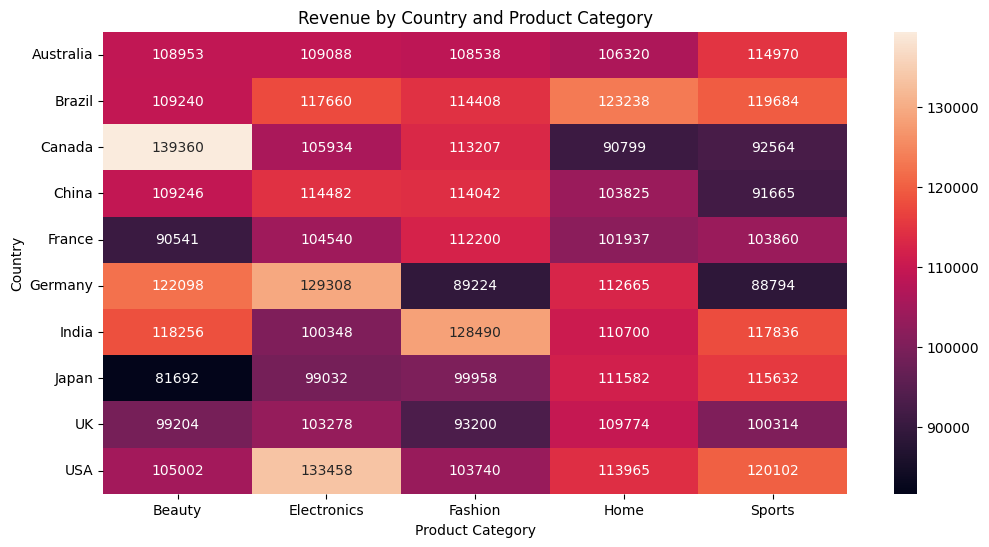

In [65]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    country_category_revenue,
    annot=True,
    fmt=".0f"
)

plt.title("Revenue by Country and Product Category")
plt.xlabel("Product Category")
plt.ylabel("Country")

plt.show()

In [66]:
top_customers = df.sort_values(
    by="estimated_revenue",
    ascending=False
).head(10)

top_customers[
    [
        "customer_id",
        "country",
        "preferred_category",
        "estimated_revenue",
        "total_orders",
        "loyalty_score"
    ]
]

,customer_id,country,preferred_category,estimated_revenue,total_orders,loyalty_score
2514,CUST_4828,Japan,Sports,8887.36,16,55
3245,CUST_5287,Brazil,Fashion,8687.18,19,8
1579,CUST_4568,USA,Sports,7159.21,23,9
4626,CUST_4957,Australia,Electronics,6894.01,17,97
3133,CUST_2913,Brazil,Sports,6264.70,13,93
3353,CUST_5117,Brazil,Sports,6229.12,16,29
395,CUST_6881,Canada,Home,5976.30,11,25
650,CUST_7996,France,Sports,5761.92,16,41
771,CUST_1876,France,Sports,5081.44,16,71
434,CUST_8668,India,Sports,5076.83,11,53


In [67]:
df.columns

Index(['customer_id', 'age', 'gender', 'country', 'avg_order_value',
       'total_orders', 'last_purchase', 'is_fraudulent', 'preferred_category',
       'email_open_rate', 'customer_since', 'loyalty_score', 'churn_risk',
       'risk_category', 'estimated_revenue', 'age_group'],
      dtype='object')

In [68]:
df.to_csv(
    "business_sales_cleaned.csv",
    index=False
)

In [69]:
from google.colab import files

files.download("business_sales_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>